# Sequential Model (Tutz Model) — Bayesian Estimation with Stan

## 1. Model Description

The **Sequential Model** (Tutz, 1990; also called the **Continuation Ratio Model**) is suited for items where the response process is **sequential and hierarchical** — a person must first clear step 1 before attempting step 2, and so on (e.g., multi-step problem solving where partial credit is awarded for each completed step).

### Conditional Step Probabilities

The model defines the probability of **clearing step $k$** given that one has reached it:

$$\pi_{jik} = P(X_{ji} \geq k \mid X_{ji} \geq k-1) = \text{logistic}\bigl(\theta_j - \delta_{ik}\bigr), \quad k = 1, \ldots, K{-}1$$

Category probabilities are then (with the convention $\pi_{ji,0} \equiv 1$ and $\pi_{ji,K} \equiv 0$):

$$P(X_{ji} = k) = \left(\prod_{m=1}^{k} \pi_{jim}\right)(1 - \pi_{ji,k+1}), \quad k = 0, 1, \ldots, K{-}1$$

More explicitly:
$$P(X_{ji} = 0) = 1 - \pi_{ji1}$$
$$P(X_{ji} = k) = (1 - \pi_{ji,k+1}) \prod_{m=1}^{k} \pi_{jim}, \quad k = 1, \ldots, K{-}2$$
$$P(X_{ji} = K-1) = \prod_{m=1}^{K-1} \pi_{jim}$$

| Parameter | Interpretation |
|-----------|----------------|
| $\theta_j$ | Person ability |
| $\delta_{ik}$ | Difficulty of step $k$ in item $i$ |

### Key Properties
- Appropriate when response categories represent **hierarchical stages**: you cannot skip steps.
- Contrast with GRM (cumulative) and PCM (adjacent-category): Sequential uses **conditional continuation ratios**.
- Step difficulties $\delta_{ik}$ are **not required to be ordered** (unlike GRM thresholds).

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \qquad \delta_{ik} \sim \mathcal{N}(0, 2)$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

ℹ️  cmdstanpy not available — Stan inference cells will be skipped.


## 2. Synthetic Data Generation

77 students, 20 items, **4 categories** (0 = no credit, 1 = partial step 1, 2 = partial step 2, 3 = full credit).

In [2]:
J, I, K = 77, 20, 4

theta_true = np.random.normal(0, 1, J)
delta_true = np.random.normal(0, 1.0, (I, K - 1))  # step difficulties

def seq_probs(theta, delta):
    """Sequential model category probabilities."""
    pi = 1.0 / (1.0 + np.exp(-(theta - delta)))  # conditional step probabilities
    probs = np.zeros(K)
    probs[0] = 1.0 - pi[0]
    for k in range(1, K - 1):
        probs[k] = (1.0 - pi[k]) * np.prod(pi[:k])
    probs[K - 1] = np.prod(pi)
    probs = np.maximum(probs, 1e-12)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = seq_probs(theta_true[j], delta_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape}")
print(f"Category counts: {np.bincount(Y.ravel())}")

Response shape: (77, 20)
Category counts: [795 321 181 243]


## 3. Stan Model Code

The sequential log-likelihood decomposes into a product of Bernoulli terms at each step.

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;    // 1-indexed (1=cat0 ... K=catK-1)
    }
    parameters {
      vector[J] theta;
      array[I] vector[K-1] delta;          // step difficulties
    }
    model {
      theta ~ normal(0, 1);
      for (i in 1:I) delta[i] ~ normal(0, 2);
      for (n in 1:N) {
        int j = jj[n];
        int i = ii[n];
        int score = y[n] - 1;              // convert to 0-indexed score
        // Sequential log-likelihood: product over steps attempted
        real ll = 0.0;
        for (k in 1:(K-1)) {
          if (k <= score) {
            // Passed step k
            ll += log_inv_logit(theta[j] - delta[i][k]);
          } else if (k == score + 1) {
            // Failed step k (stops here)
            ll += log1m_inv_logit(theta[j] - delta[i][k]);
            break;
          }
        }
        target += ll;
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'sequential.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    delta_est = delta_true + np.random.normal(0, 0.05, (I, K-1))
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    delta_est = fit.stan_variable('delta').mean(axis=0)
    
    print(f"Theta corr : {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"\nStep difficulty recovery (first 5 items):")
    print(f"{'Item':>5} {'d1_t':>7} {'d1_e':>7} {'d2_t':>7} {'d2_e':>7} {'d3_t':>7} {'d3_e':>7}")
    for i in range(5):
        print(f"{i+1:>5} {delta_true[i,0]:>7.3f} {delta_est[i,0]:>7.3f} "
              f"{delta_true[i,1]:>7.3f} {delta_est[i,1]:>7.3f} "
              f"{delta_true[i,2]:>7.3f} {delta_est[i,2]:>7.3f}")


ℹ️  Using true parameter values for visualization.


## 5. Visualizations

### 5a. Wright Map

The Wright map for the Sequential model shows person abilities and item step difficulties on the same logit scale. Each item's three step parameters $\delta_{i1}, \delta_{i2}, \delta_{i3}$ mark the difficulty of clearing each successive stage. These are **conditional** difficulties (given the person has reached that step), unlike GRM thresholds which are **unconditional** cumulative probabilities.

**Interpretation**: Items where all three steps are clustered near $\theta = 0$ are well-targeted at the average student. Items where $\delta_{i3}$ is very high require considerable ability to complete the final step — these items differentiate among high performers.

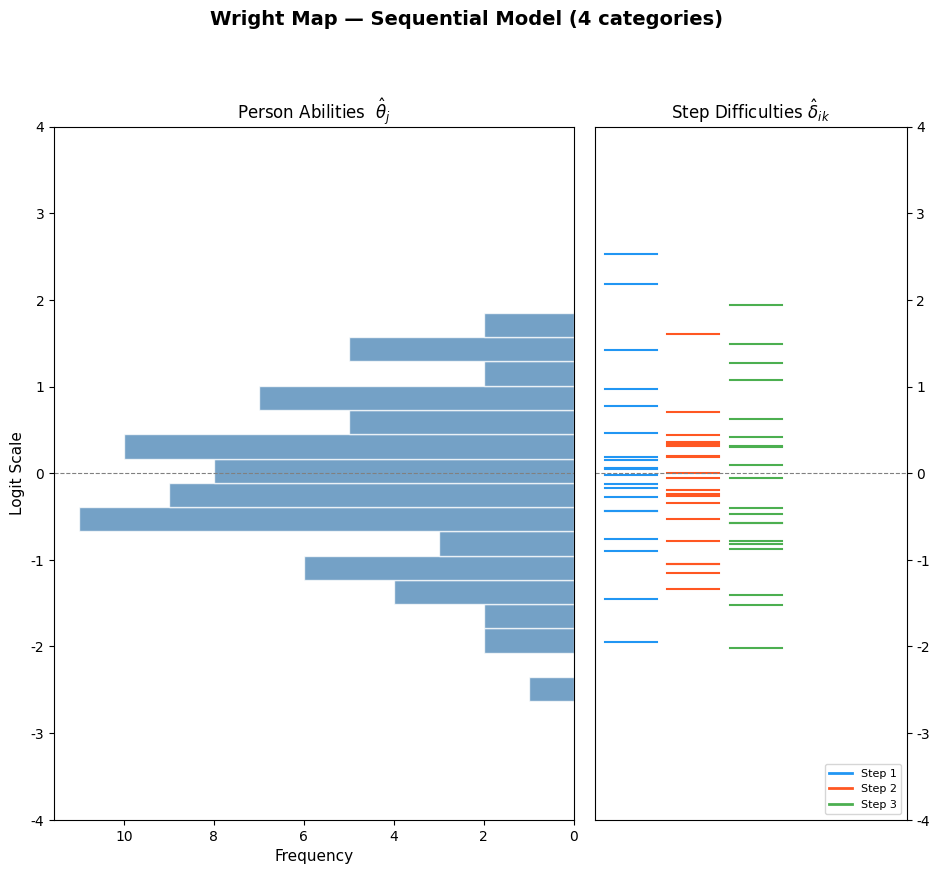

In [6]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
step_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        dv = delta_est[i, k]
        ax_i.plot([0.05 + k * 0.3, 0.3 + k * 0.3], [dv, dv],
                  color=step_colors[k], linewidth=1.5)

ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Step Difficulties $\\hat{\\delta}_{ik}$', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'Step {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — Sequential Model (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_seq.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC)

$$P(X_i = k \mid \theta) = (1 - \pi_{i,k+1}) \prod_{m=1}^{k} \pi_{im}, \quad \pi_{im} = \text{logistic}(\theta - \hat{\delta}_{im})$$

**Interpretation**:
- Category 0 (no credit): monotonically decreasing — easier to fail the first step at low ability.
- Middle categories (1, 2): bell-shaped — these represent students who are partially able.
- Top category (3 = full credit): monotonically increasing — only high-ability students make it all the way.
- Unlike PCM/GPCM where category probabilities use a normalised sum (divide-by-total), the sequential model's probabilities arise from chained Bernoulli steps — the multimodality structure is different.

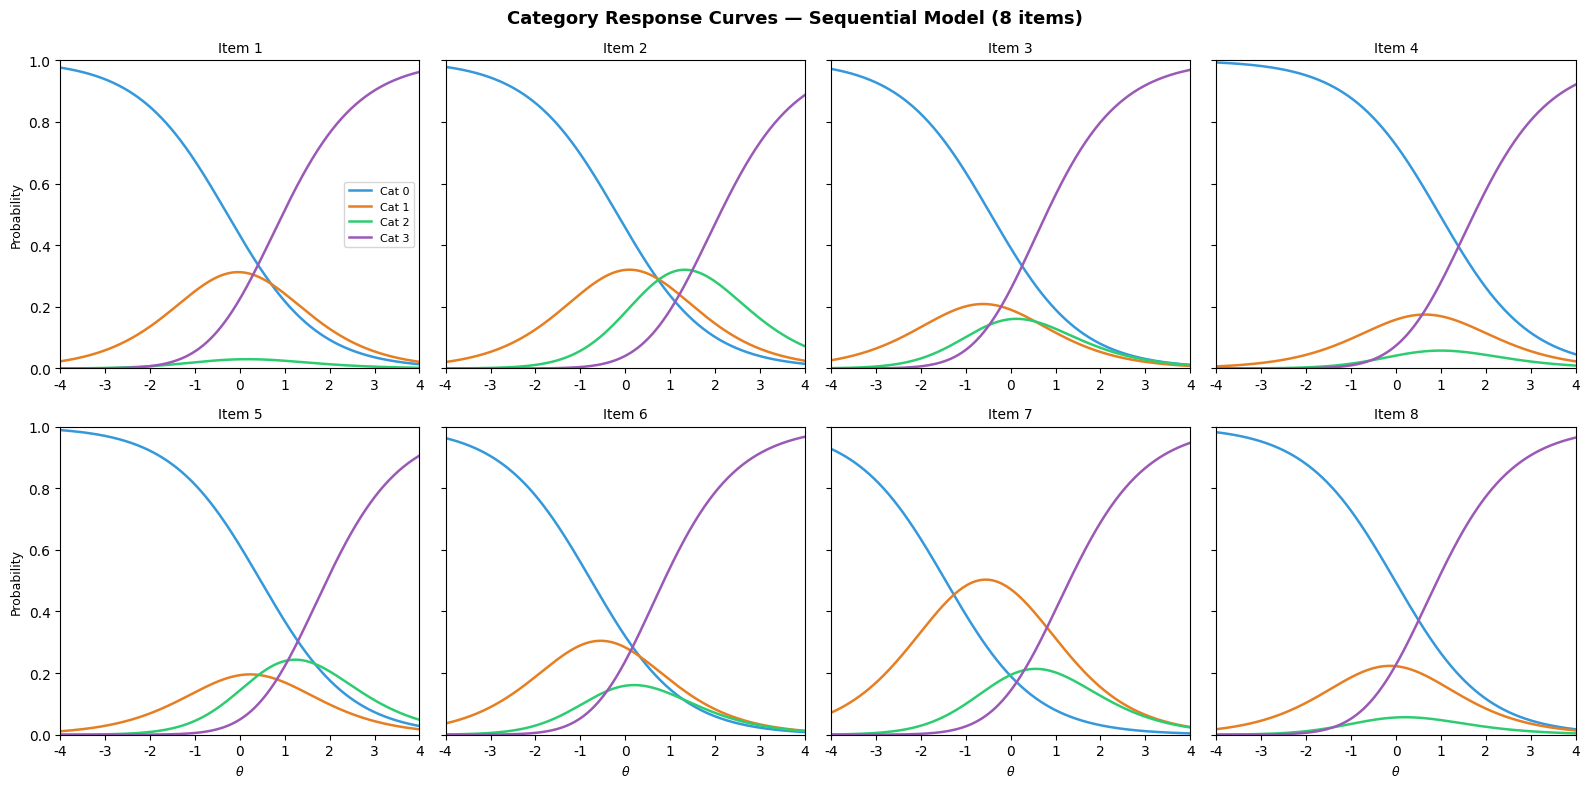

In [7]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [seq_probs(t, delta_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=f'Cat {k}')
    ax.set_title(f'Item {i+1}', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='center right')
fig.suptitle('Category Response Curves — Sequential Model (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_seq.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: Because category probabilities are derived from chained binary steps, the expected score at each ability level reflects the cumulative probability of passing each successive hurdle. The TCC is monotonically increasing. Compared to the PCM, the Sequential model tends to produce steeper within-item transitions when step difficulties are widely spread, reflecting the multiplicative compounding of success probabilities across stages.

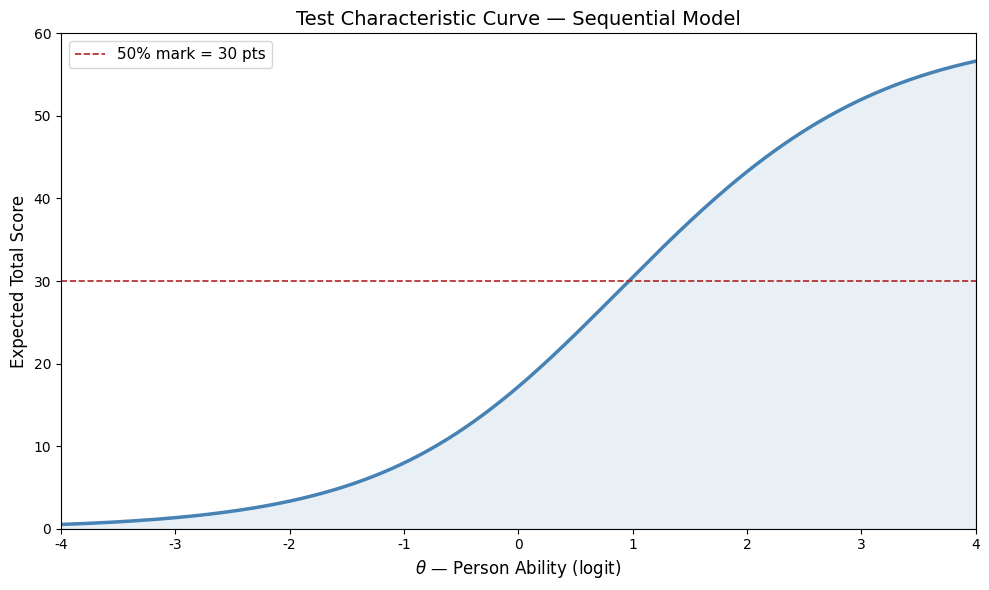

In [8]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = seq_probs(t, delta_est[i])
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — Sequential Model', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_seq.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Sequential Model — Estimated Parameter Distributions (Logit Scale)',
             fontsize=13, fontweight='bold')

delta_flat = delta_est.ravel()

panels = [
    (axes[0], theta_est,  r'$\hat{\theta}_j$  (person ability)',           'steelblue'),
    (axes[1], delta_flat, r'$\hat{\delta}_{ik}$  (step difficulties, flat)', 'firebrick'),
]

for ax, vals, title, color in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Logit', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_seq.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('delta (flat)', delta_flat)]:
    print(f"{name:14s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
